# Install libraries and import to Venv

In [19]:
!pip install seaborn
!pip install matplotlib
!pip install pandas

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Functions

def heatmap_correlation(df):
    plt.figure(figsize=(10, 8)) 
    sns.heatmap(corr_matrix, annot= True, fmt='.2f', cmap='coolwarm')
    plt.title('Correlation Heatmap of Numeric Features')
    plt.show()



# Import Dataset

In [77]:
df = pd.read_csv('train.csv')
df.head()

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,0,0.00,No,6.00,4.00,No,15.00,5.00,Extrovert
1,1,1.00,No,7.00,3.00,No,10.00,8.00,Extrovert
2,2,6.00,Yes,1.00,0.00,NaN,3.00,0.00,Introvert
3,3,3.00,No,7.00,3.00,No,11.00,5.00,Extrovert
4,4,1.00,No,4.00,4.00,No,13.00,NaN,Extrovert


In [78]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Exploring data for insights

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18524 entries, 0 to 18523
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         18524 non-null  int64  
 1   Time_spent_Alone           17334 non-null  float64
 2   Stage_fear                 16631 non-null  object 
 3   Social_event_attendance    17344 non-null  float64
 4   Going_outside              17058 non-null  float64
 5   Drained_after_socializing  17375 non-null  object 
 6   Friends_circle_size        17470 non-null  float64
 7   Post_frequency             17260 non-null  float64
 8   Personality                18524 non-null  object 
dtypes: float64(5), int64(1), object(3)
memory usage: 1.3+ MB


In [80]:
df.describe()

,id,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
count,18524.00,17334.00,17344.00,17058.00,17470.00,17260.00
mean,9261.50,3.14,5.27,4.04,8.00,4.98
std,5347.56,3.00,2.75,2.06,4.22,2.88
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,4630.75,1.00,3.00,3.00,5.00,3.00
50%,9261.50,2.00,5.00,4.00,8.00,5.00
75%,13892.25,4.00,8.00,6.00,12.00,7.00
max,18523.00,11.00,10.00,7.00,15.00,10.00


# Checking Null Values

In [81]:
df.isnull().sum()

id                              0
Time_spent_Alone             1190
Stage_fear                   1893
Social_event_attendance      1180
Going_outside                1466
Drained_after_socializing    1149
Friends_circle_size          1054
Post_frequency               1264
Personality                     0
dtype: int64

# Checking Unique Values

In [82]:
df.nunique()

id                           18524
Time_spent_Alone                12
Stage_fear                       2
Social_event_attendance         11
Going_outside                    8
Drained_after_socializing        2
Friends_circle_size             16
Post_frequency                  11
Personality                      2
dtype: int64

## Replace stage fear and drained after socializing from Yes/No to 1/0

In [83]:
train_df = df
train_df['Stage_fear'] = train_df['Stage_fear'].replace({'Yes': 1, 'No': 0})
train_df['Drained_after_socializing'] = train_df['Drained_after_socializing'].replace({'Yes': 1, 'No': 0})
train_df['Personality'] = train_df['Personality'].replace({'Extrovert': 1, 'Introvert': 0})  

C:\Users\I748073\AppData\Local\Temp\ipykernel_27112\1831112470.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_df['Stage_fear'] = train_df['Stage_fear'].replace({'Yes': 1, 'No': 0})
C:\Users\I748073\AppData\Local\Temp\ipykernel_27112\1831112470.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_df['Drained_after_socializing'] = train_df['Drained_after_socializing'].replace({'Yes': 1, 'No': 0})
C:\Users\I748073\AppData\Local\Temp\ipykernel_27112\1831112470.py:4: FutureWarning: Downcasting behavior in `replace` is d

## Selecting only numeric columns

In [84]:
numeric_df = train_df.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_df.corr()

# Explanation: Correlation Heatmap Code

This section breaks down each line of the heatmap plotting code in Python using `matplotlib` and `seaborn`.

---

##  `plt.figure(figsize=(10, 8))`
Creates a new figure (canvas) for plotting.

- `figsize=(10, 8)` sets the width to **10 inches** and height to **8 inches**.
- Without this, your plot may appear too small or cramped in a Jupyter notebook.

---

##  `sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')`
Generates a heatmap based on a correlation matrix.

### Parameters:

| Argument        | Description                                                                 |
|-----------------|-----------------------------------------------------------------------------|
| `corr_matrix`   | A DataFrame of correlation values (e.g., from `df.corr()`)                  |
| `annot=True`    | Displays the numeric correlation values on each square                      |
| `fmt=".2f"`     | Formats the annotation values to **2 decimal places**                       |
| `cmap='coolwarm'` | Applies a blue-to-red gradient (blue = negative, red = positive correlation) |

---

##  `plt.title('Correlation Heatmap of Numeric Features')`
Adds a title to the top of your heatmap for context.

---

##  `plt.show()`
Renders the plot inside the notebook cell.

---


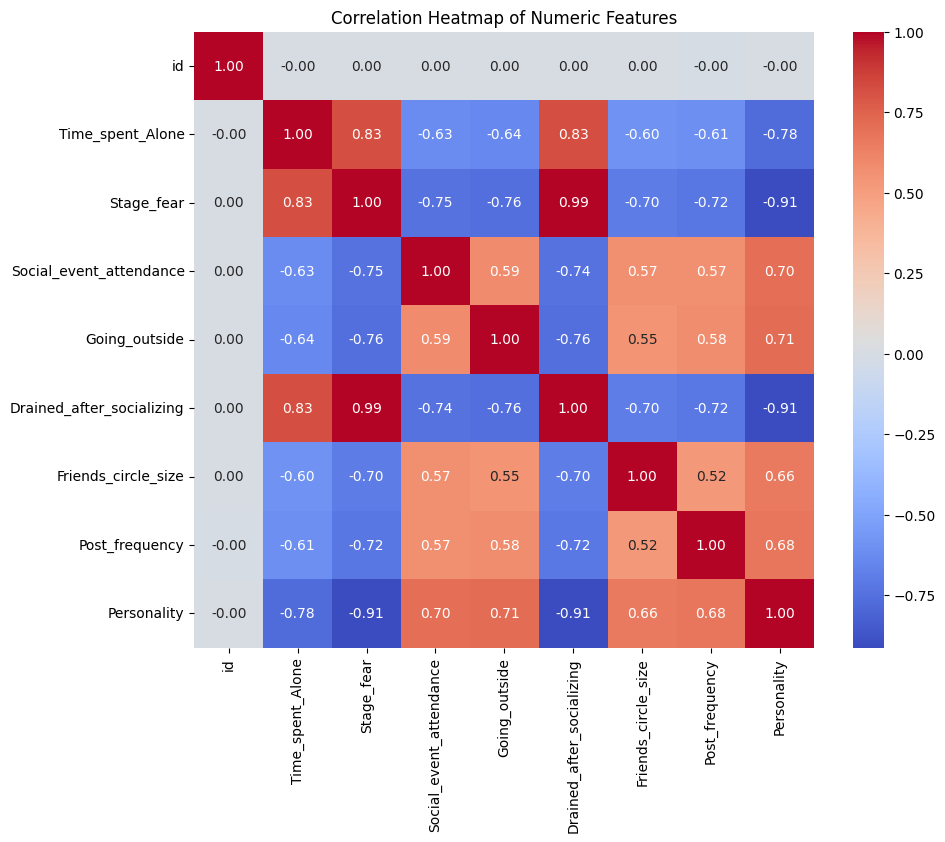

In [85]:
plt.figure(figsize=(10, 8)) 
sns.heatmap(corr_matrix, annot= True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

## adding same replacement to test_df to check if correlation is the same

In [86]:
test_df = pd.read_csv('test.csv')
test_df.head()

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency
0,18524,3.00,No,7.00,4.00,No,6.00,NaN
1,18525,NaN,Yes,0.00,0.00,Yes,5.00,1.00
2,18526,3.00,No,5.00,6.00,No,15.00,9.00
3,18527,3.00,No,4.00,4.00,No,5.00,6.00
4,18528,9.00,Yes,1.00,2.00,Yes,1.00,1.00


In [87]:

test_df['Stage_fear'] = test_df['Stage_fear'].replace({'Yes': 1, 'No': 0})
test_df['Drained_after_socializing'] = test_df['Drained_after_socializing'].replace({'Yes': 1, 'No': 0}) 

C:\Users\I748073\AppData\Local\Temp\ipykernel_27112\2114821326.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_df['Stage_fear'] = test_df['Stage_fear'].replace({'Yes': 1, 'No': 0})
C:\Users\I748073\AppData\Local\Temp\ipykernel_27112\2114821326.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_df['Drained_after_socializing'] = test_df['Drained_after_socializing'].replace({'Yes': 1, 'No': 0})


In [88]:
test_numeric_df = test_df.select_dtypes(include=['float64', 'int64'])
test_corr_matrix = test_numeric_df.corr()

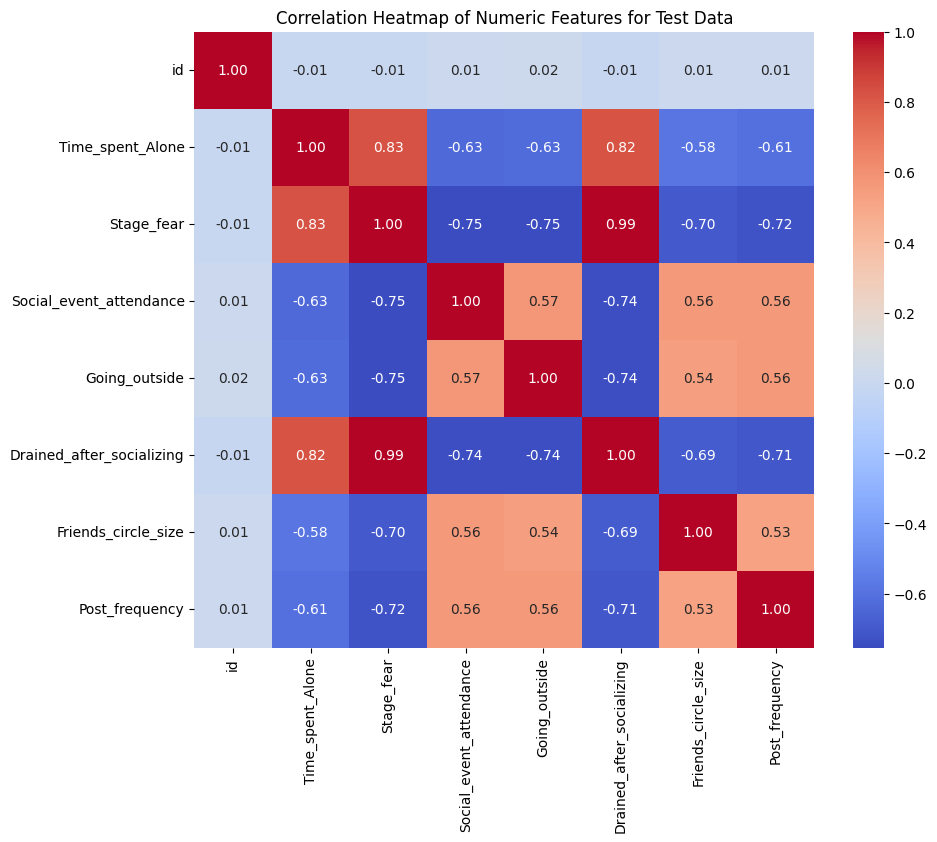

In [89]:
plt.figure(figsize=(10, 8)) 
sns.heatmap(test_corr_matrix, annot= True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap of Numeric Features for Test Data')
plt.show()

# Back to train DF exploration

In [92]:
df['Personality'] = train_df['Personality'].replace({1: 'Extrovert', 0: 'Introvert'})

In [93]:
df.groupby('Personality').mean()

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency
Personality,,,,,,,,
Extrovert,9256.82,1.75,0.02,6.39,4.90,0.02,9.62,6.11
Introvert,9274.79,7.05,0.93,1.93,1.53,0.92,3.26,1.61


In [94]:
df.groupby('Personality').max()

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency
Personality,,,,,,,,
Extrovert,18523,11.00,1.00,10.00,7.00,1.00,15.00,10.00
Introvert,18522,11.00,1.00,10.00,7.00,1.00,15.00,10.00


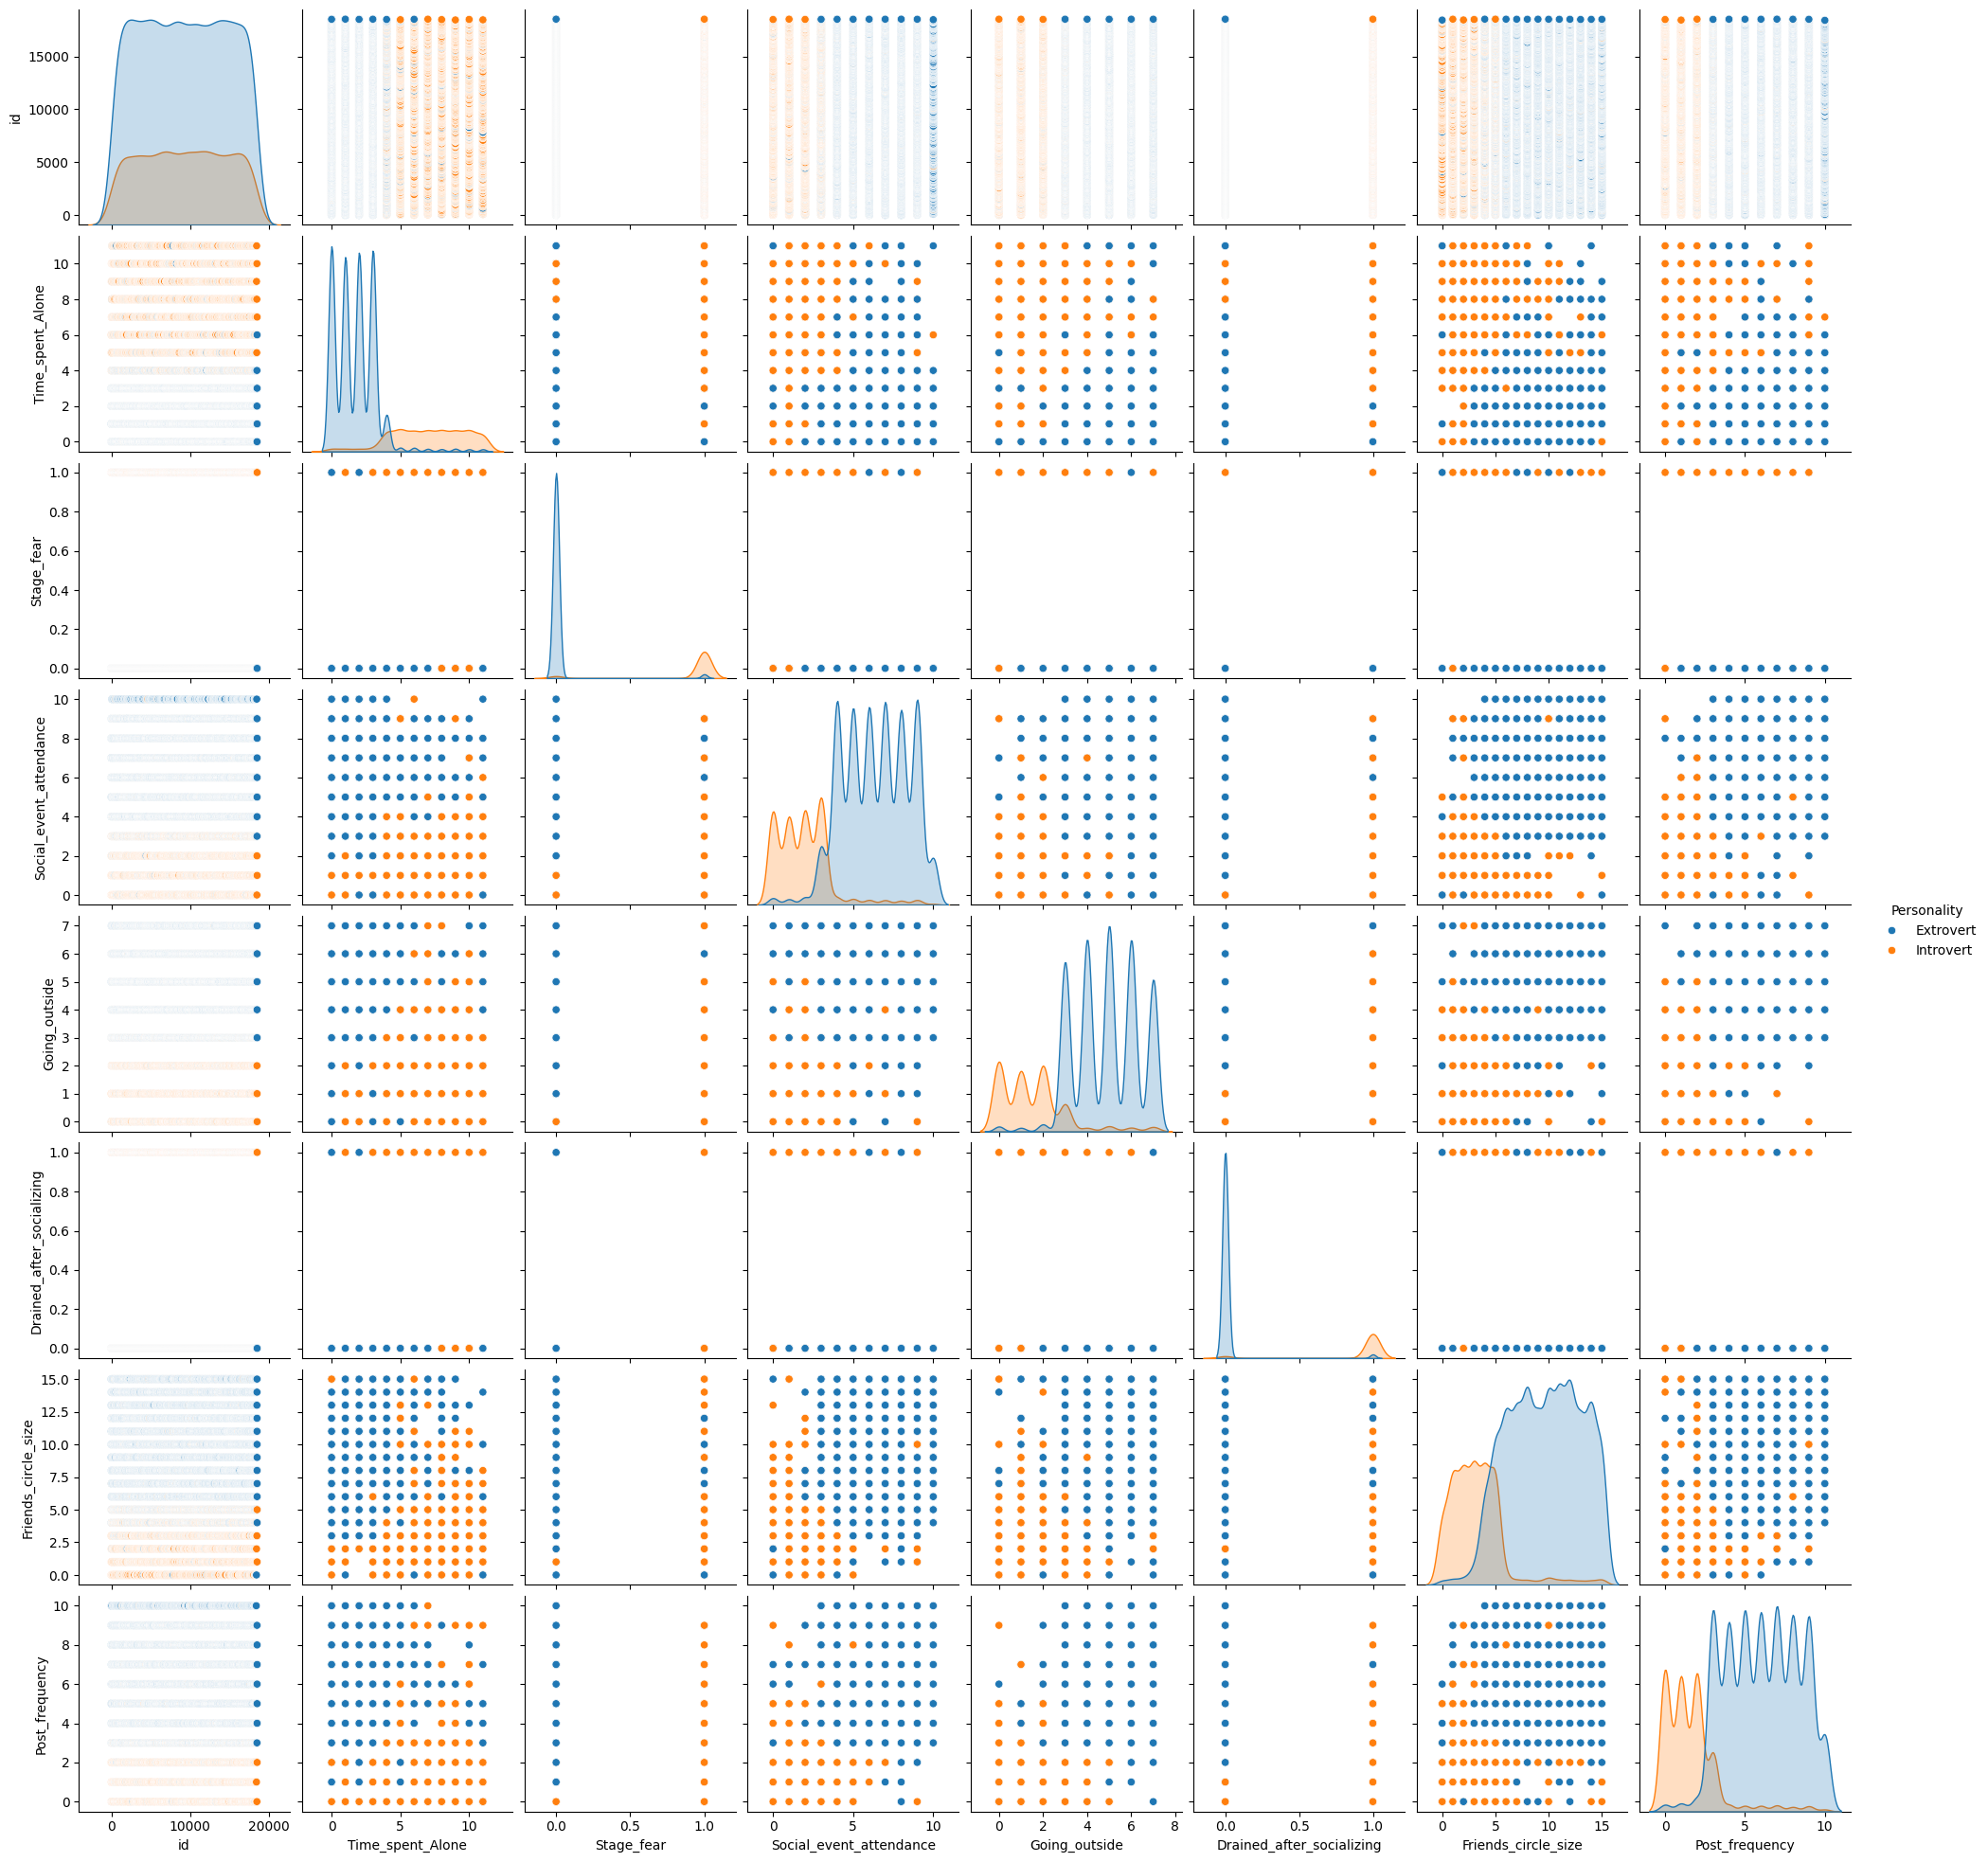

In [99]:
sns.pairplot(df, hue = 'Personality')